In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
datos_maraton = pd.read_csv('DatosMaratonenCSV.csv')
print("Datos cargados correctamente.")

Datos cargados correctamente.


In [3]:
datos_maraton['Wall21'] = pd.to_numeric(datos_maraton['Wall21'], errors='coerce')

In [4]:
datos_maraton = datos_maraton.drop(columns=['Name', 'id', 'Marathon', 'CATEGORY'])

In [5]:
print("Columnas innecesarias eliminadas.")

Columnas innecesarias eliminadas.


In [6]:
datos_maraton["CrossTraining"] = datos_maraton["CrossTraining"].fillna(0)
datos_maraton = datos_maraton.dropna(how='any')

In [7]:
valores_cross = {"CrossTraining":  {'ciclista 1h':1, 'ciclista 3h':2, 'ciclista 4h':3, 'ciclista 5h':4, 'ciclista 13h':5}}
datos_maraton.replace(valores_cross, inplace=True)

/tmp/ipykernel_2843/3845657131.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_maraton.replace(valores_cross, inplace=True)


In [8]:
valores_categoria = {"Category":  {'MAM':1, 'M45':2, 'M40':3, 'M50':4, 'M55':5,'WAM':6}}
datos_maraton.replace(valores_categoria, inplace=True)

/tmp/ipykernel_2843/759892515.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_maraton.replace(valores_categoria, inplace=True)


In [9]:
print("Datos limpios y convertidos a formato numérico.")

Datos limpios y convertidos a formato numérico.


In [10]:
datos_maraton = datos_maraton.query('sp4week<1000')

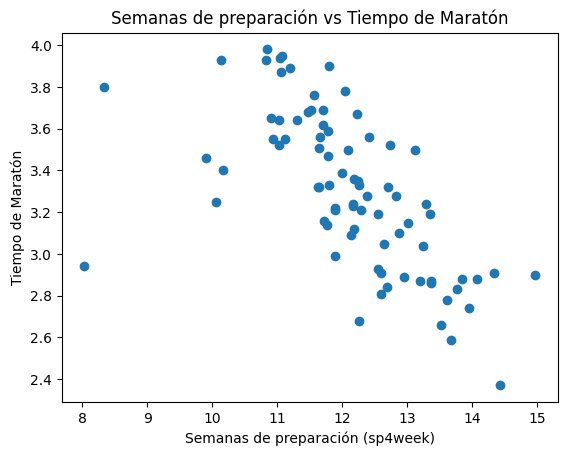

In [11]:
plt.scatter(x=datos_maraton['sp4week'], y=datos_maraton['MarathonTime'])
plt.title('Semanas de preparación vs Tiempo de Maratón')
plt.xlabel('Semanas de preparación (sp4week)')
plt.ylabel('Tiempo de Maratón')
plt.show()

In [12]:
datos_entrenamiento = datos_maraton.sample(frac=0.8, random_state=0)
datos_test = datos_maraton.drop(datos_entrenamiento.index)

In [13]:
etiquetas_entrenamiento = datos_entrenamiento.pop('MarathonTime')
etiquetas_test = datos_test.pop('MarathonTime')

In [14]:
modelo = LinearRegression()
modelo.fit(datos_entrenamiento, etiquetas_entrenamiento)

LinearRegression()

In [15]:
print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [16]:
predicciones = modelo.predict(datos_test)
error = np.sqrt(mean_squared_error(etiquetas_test, predicciones))
print(f"Error porcentual del modelo: {error*100:.2f}%")

Error porcentual del modelo: 11.03%


In [17]:
nuevo_corredor = pd.DataFrame(np.array([[1, 400, 20, 0, 1.4]]), columns=['Category', 'km4week','sp4week', 'CrossTraining','Wall21'])

In [18]:
prediccion_nuevo = modelo.predict(nuevo_corredor)
print(f"\nEl tiempo estimado para el nuevo corredor es: {prediccion_nuevo[0]:.2f} horas")


El tiempo estimado para el nuevo corredor es: 2.20 horas
